In [1]:
import scipy
#print(scipy.__version__)

from scipy import constants
print(constants.pi)
print(constants.atm)
print(constants.ounce)
print(constants.g)

3.141592653589793
101325.0
0.028349523124999998
9.80665


Start with simple SciPy examples
A. Solving linear equations
Suppose:

2x+y=8

x+3y=13

Write this as 
Ax=b:

scipy.linalg---->	Linear algebra

scipy.optimize---->	Optimization and equation solving

scipy.integrate---->	Numerical integration and differential equations

scipy.interpolate---->	Estimating values between known data points

scipy.stats---->	Probability and statistical distributions

scipy.signal---->	Signal processing

In [2]:
from scipy.linalg import solve
import numpy as np

In [3]:
A = np.array([[2,1],
              [1,3]])
b = np.array([8,13])

solution = solve(A,b)
solution

array([2.2, 3.6])

## Solving sqr-root problem

In [4]:
from scipy.optimize import root_scalar
def f(x):
    return x**2-4*x+3

result = root_scalar(f,bracket=[2,4])
print(result.root)

2.9999999999999996


In [5]:
from scipy import constants

print(constants.pi)

3.141592653589793


### A list of all units under the constants module can be seen using the dir() function.

In [6]:
dir(constants)

['Avogadro',
 'Boltzmann',
 'Btu',
 'Btu_IT',
 'Btu_th',
 'ConstantWarning',
 'G',
 'Julian_year',
 'N_A',
 'Planck',
 'R',
 'Rydberg',
 'Stefan_Boltzmann',
 'Wien',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_codata',
 '_constants',
 '_obsolete_constants',
 'acre',
 'alpha',
 'angstrom',
 'arcmin',
 'arcminute',
 'arcsec',
 'arcsecond',
 'astronomical_unit',
 'atm',
 'atmosphere',
 'atomic_mass',
 'atto',
 'au',
 'bar',
 'barrel',
 'bbl',
 'blob',
 'c',
 'calorie',
 'calorie_IT',
 'calorie_th',
 'carat',
 'centi',
 'codata',
 'constants',
 'convert_temperature',
 'day',
 'deci',
 'degree',
 'degree_Fahrenheit',
 'deka',
 'dyn',
 'dyne',
 'e',
 'eV',
 'electron_mass',
 'electron_volt',
 'elementary_charge',
 'epsilon_0',
 'erg',
 'exa',
 'exbi',
 'femto',
 'fermi',
 'find',
 'fine_structure',
 'fluid_ounce',
 'fluid_ounce_US',
 'fluid_ounce_imp',
 'foot',
 'g',
 'gallon',
 'gallon_US',
 'g

Unit Categories
The units are placed under these categories:

- Metric
- Binary
- Mass
- Angle
- Time
- Length
- Pressure
- Volume
- Speed
- Temperature
- Energy
- Power
- Force

In [8]:
print(constants.kibi)    #1024
print(constants.mebi)    #1048576
print(constants.gibi)

1024
1048576
1073741824


In terms of **Kg**

In [9]:
print(constants.gram)    
print(constants.metric_ton)    
print(constants.pound)
print(constants.carat)    
print(constants.ounce)    
print(constants.lb)

0.001
1000.0
0.45359236999999997
0.0002
0.028349523124999998
0.45359236999999997


In term of **second**

In [11]:
print(constants.minute)
print(constants.week)
print(constants.day)

60.0
604800.0
86400.0


In term of **meter**

In [12]:
print(constants.inch)
print(constants.foot)
print(constants.yard)
print(constants.mile)
print(constants.angstrom)

0.0254
0.30479999999999996
0.9143999999999999
1609.3439999999998
1e-10


In term of **pascal**

In [13]:
print(constants.atm)
print(constants.bar)
print(constants.torr)

101325.0
100000.0
133.32236842105263


- **Area** - hectre, Acre - squere meter
- **Volume** - Litre, gallon * cubic meter
- **Speed** - kmh,mph - m/s
- **Temp** - zero_Celsius, degree_Fahrenheit - Kelvin
- **Energy** - eV, calorie, erg - joules
- **Power** - hp - watts
- **Force** - dyne,kgf,pound_force - newton

## **Optimization**

**NumPy is capable of finding roots for polynomials and linear equations, but it can not find roots for non linear equations, like this one:**

In [19]:
from scipy.optimize import root
from math import cos

def eqn(x):
    return x + cos(x)

my_root = root(eqn,0)
print(myroot.x)

TypeError: only 0-dimensional arrays can be converted to Python scalars

The built-in Python *math.cos* function is strict: **it only accepts a single standalone number (a scalar)**. It has no idea what to do if you pass it an array.

When you pass your equation to *scipy.optimize.root*, SciPy does not feed a simple number like 0 into eqn(x). Under the hood, SciPy wraps the input into a NumPy array to handle multidimensional vector calculations. Because x becomes an array, math.cos(x) tries to force that array into a single number, causing NumPy to throw the TypeError

Replace *math.cos* with **numpy.cos**. NumPy's version is designed to handle arrays and automatically performs the math operation on everything inside the array.

In [22]:
from scipy.optimize import root
from numpy import cos

def eqn(x):
    return x + cos(x)

my_root = root(eqn,0)
print(my_root)

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00]
       x: [-7.391e-01]
  method: hybr
    nfev: 11
    fjac: [[-1.000e+00]]
       r: [-1.674e+00]
     qtf: [-2.668e-13]


## **Minimising a function**

### **minima**
- *scipy.optimize.minimize()*

The minimize() function takes the following arguments:

**fun** - a function representing an equation.

**x0** - an initial guess for the root.

**method** - name of the method to use. Legal values:
- 'CG'
- 'BFGS'
- 'Newton-CG'
- 'L-BFGS-B'
- 'TNC'
- 'COBYLA'
- 'SLSQP'

callback - function called after each iteration of optimization.

In [23]:
from scipy.optimize import minimize

def eqn(x):
    return (x**2)+(3*x)+4

mymin = minimize(eqn, 0, method='BFGS')
mymin

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.75
        x: [-1.500e+00]
      nit: 2
      jac: [ 0.000e+00]
 hess_inv: [[ 5.000e-01]]
     nfev: 6
     njev: 3

In [2]:
import numpy as np
from scipy.optimize import minimize
import math

#### **.success is an attribute or property used to check if an operation completed successfully without errors.**

#### *scipy.optimize.minimize* is designed for multi-variable problems. It always expects **an array-like structure** (a list or a NumPy array), even if you only have one variable.

In [3]:
def fun(x):
    return (x**2)+(4*x)+3

# we have to provide initial guess 
ini_guess = [0.0] # why in the list 
result = minimize(fun,ini_guess)

# extract result
if result.success:
    print(f"Optimal Solution {result.x}")
    print(f"Minimum value of f(x) is : {result.fun}")
else:
    print("Optimsation Failed")

Optimal Solution [-2.00000002]
Minimum value of f(x) is : -1.0


Optimal Solution [-2.00000002]
Minimum value of f(x) is : -1.0


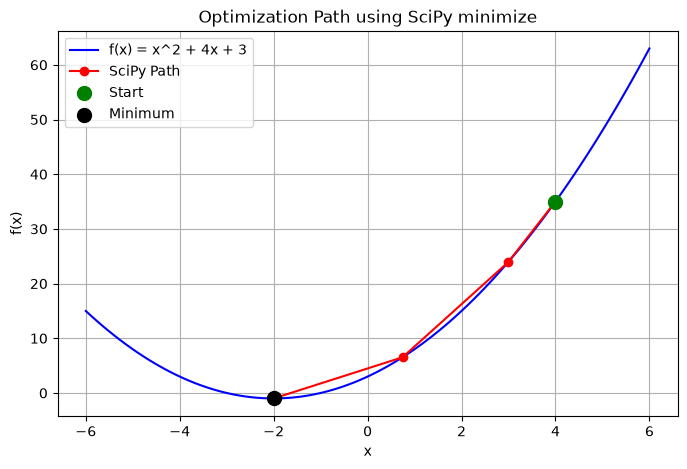

In [5]:
import matplotlib.pyplot as plt
def fun(x):
    return (x**2)+(4*x)+3

# 1. Set the initial guess (starting at 4.0 to make the graph's path visible)
ini_guess = [4.0]

# 2. Create a list to store the path, starting with our initial guess
x_history = [ini_guess[0]]

# 3. Define the callback function to save 'x' at each step
def save_step(xk):
    # xk is the current array of variables. We only have one, so we grab xk[0]
    x_history.append(xk[0])

# 4. Run minimize, passing our save_step function to the callback
result = minimize(fun, ini_guess, callback=save_step)

# extract result
if result.success:
    print(f"Optimal Solution {result.x}")
    print(f"Minimum value of f(x) is : {result.fun}")
else:
    print("Optimsation Failed")
    
# --- Plotting ---

y_history = [fun(x) for x in x_history]

# Generate smooth data for the background curve
x_vals = np.linspace(-6, 6, 100)
y_vals = fun(x_vals)

plt.figure(figsize=(8, 5))

# Plot the main function curve
plt.plot(x_vals, y_vals, label='f(x) = x^2 + 4x + 3', color='blue')

# Plot the optimization steps taken by SciPy
plt.plot(x_history, y_history, 'ro-', label='SciPy Path', markersize=6)

# Highlight start and end
plt.scatter(x_history[0], y_history[0], color='green', s=100, label='Start', zorder=5)
plt.scatter(x_history[-1], y_history[-1], color='black', s=100, label='Minimum', zorder=5)

plt.title('Optimization Path using SciPy minimize')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()